## 1. Importación de Librerías y Carga de Datos
En esta sección se importan las herramientas necesarias para el análisis de datos (Pandas y NumPy) y se monta la unidad de Google Drive para cargar el dataset original `H1N1_Flu_Vaccines.csv`.

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
from matplotlib import pyplot

drive.mount('/content/drive')

ruta_archivo = '/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/H1N1_Flu_Vaccines.csv'
df_crudo = pd.read_csv(ruta_archivo)

print(f"Dataset cargado exitosamente.")
print(f"Tamaño original: {df_crudo.shape[0]} filas y {df_crudo.shape[1]} columnas.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado exitosamente.
Tamaño original: 26707 filas y 38 columnas.


## 2. Preprocesamiento de Datos
Limpieza del dataset mediante la evaluación de valores nulos (NaN). Se eliminan columnas que superan el umbral permitido de nulos o que no aportan al modelo predictivo. Posteriormente, se aplica imputación de datos (interpolación para variables numéricas y moda para variables categóricas) y se transforman los datos de texto a valores numéricos mediante variables *Dummies*.

In [4]:
print("\n--- INICIANDO ANÁLISIS DE NULOS ---")

nulos_por_columna = df_crudo.isnull().sum()
limite_nulos = 12000
columnas_con_muchos_nulos = nulos_por_columna[nulos_por_columna > limite_nulos].index.tolist()

print(f"Columnas que superan el límite de {limite_nulos} nulos y serán eliminadas:")
for col in columnas_con_muchos_nulos:
    print(f" - {col}: {nulos_por_columna[col]} nulos")

columnas_a_eliminar = ['respondent_id', 'h1n1_vaccine'] + columnas_con_muchos_nulos
df_limpio = df_crudo.drop(columns=columnas_a_eliminar)
print(f"Columnas eliminadas. El dataset pasó de {df_crudo.shape[1]} a {df_limpio.shape[1]} columnas.")

cols_numericas = df_limpio.select_dtypes(include=[np.number]).columns
cols_texto = df_limpio.select_dtypes(include=['object']).columns

df_limpio[cols_numericas] = df_limpio[cols_numericas].interpolate(method='linear')
df_limpio[cols_numericas] = df_limpio[cols_numericas].fillna(0)

for col in cols_texto:
    valor_mas_frecuente = df_limpio[col].mode()[0]
    df_limpio[col] = df_limpio[col].fillna(valor_mas_frecuente)

nulos_restantes = df_limpio.isnull().sum().sum()
print(f"Valores nulos restantes tras la imputación: {nulos_restantes}")

df_final = pd.get_dummies(df_limpio, drop_first=True, dtype=int)
print(f"Tamaño después de aplicar Dummies: {df_final.shape[0]} filas y {df_final.shape[1]} columnas.\n")


--- INICIANDO ANÁLISIS DE NULOS ---
Columnas que superan el límite de 12000 nulos y serán eliminadas:
 - health_insurance: 12274 nulos
 - employment_industry: 13330 nulos
 - employment_occupation: 13470 nulos
Columnas eliminadas. El dataset pasó de 38 a 33 columnas.
Valores nulos restantes tras la imputación: 0
Tamaño después de aplicar Dummies: 26707 filas y 51 columnas.



## 3. Análisis de Estructura de Variables
Se verifica la variable objetivo elegida (`seasonal_vaccine`) para comprobar que el dataset se encuentre balanceado. Además, se clasifican las variables independientes o características predictivas ($X$) para un mejor entendimiento del conjunto de datos.

In [5]:
print("LA VARIABLE OBJETIVO (Y)")
print("-" * 50)
distribucion_y = df_final['seasonal_vaccine'].value_counts(normalize=True) * 100
print(f"Variable elegida: 'seasonal_vaccine' (Si recibió la vacuna estacional o no)")
print(f"Clase 0 (No se vacunó): {distribucion_y[0]:.2f}%")
print(f"Clase 1 (Sí se vacunó): {distribucion_y[1]:.2f}%")
print("-> Balance casi perfecto (50/50). Ideal para el modelo sigmoidal.\n")

print("ESTRUCTURA DE LAS CARACTERÍSTICAS (X)")
print("-" * 50)
columnas_actuales = list(df_final.columns)
columnas_actuales.remove('seasonal_vaccine')

comportamiento = [c for c in columnas_actuales if c.startswith('behavioral') or c.startswith('opinion') or c.startswith('h1n1')]
medicas = [c for c in columnas_actuales if c.startswith('doctor') or c.startswith('chronic') or c.startswith('health_worker')]
demografia = [c for c in columnas_actuales if c not in comportamiento and c not in medicas]

print(f"Total de características predictivas (X): {len(columnas_actuales)}\n")

print("1. Comportamiento y Opiniones:")
for col in comportamiento[:5]: print(f"   - {col}")
if len(comportamiento) > 5: print("   - ...")

print("\n2. Recomendaciones y Estado Médico:")
for col in medicas: print(f"   - {col}")

print("\n3. Demografía (Expandidas con Dummies):")
for col in demografia[:5]: print(f"   - {col}")
if len(demografia) > 5: print("   - ...")

LA VARIABLE OBJETIVO (Y)
--------------------------------------------------
Variable elegida: 'seasonal_vaccine' (Si recibió la vacuna estacional o no)
Clase 0 (No se vacunó): 53.44%
Clase 1 (Sí se vacunó): 46.56%
-> Balance casi perfecto (50/50). Ideal para el modelo sigmoidal.

ESTRUCTURA DE LAS CARACTERÍSTICAS (X)
--------------------------------------------------
Total de características predictivas (X): 50

1. Comportamiento y Opiniones:
   - h1n1_concern
   - h1n1_knowledge
   - behavioral_antiviral_meds
   - behavioral_avoidance
   - behavioral_face_mask
   - ...

2. Recomendaciones y Estado Médico:
   - doctor_recc_h1n1
   - doctor_recc_seasonal
   - chronic_med_condition
   - health_worker

3. Demografía (Expandidas con Dummies):
   - child_under_6_months
   - household_adults
   - household_children
   - age_group_35 - 44 Years
   - age_group_45 - 54 Years
   - ...


## 4. Definición de Funciones Matemáticas
Se declaran las funciones esenciales de cálculo manual necesarias para aplicar la Regresión Logística:
*   Función Sigmoide ($g(z)$)
*   Normalización de características para escalado unificado
*   Cálculo de la Función de Costo ($J(\theta)$)

In [6]:
def sigmoid(z):
    z = np.array(z)
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))
    return g

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

def calcularCosto(theta, X, y):
    m = y.size
    epsilon = 1e-15
    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h + epsilon)) - (1 - y).dot(np.log(1 - h + epsilon)))
    return J

print("Funciones matemáticas declaradas correctamente.")

Funciones matemáticas declaradas correctamente.


## 5. Entrenamiento del Modelo (Descenso por el Gradiente)
Procedemos a separar el dataset en un conjunto de entrenamiento (80%) y prueba (20%). Los datos de entrenamiento son convertidos a arreglos vectorizados, normalizados, y se les aplica el algoritmo de Descenso por el Gradiente para entrenar a los Thetas (parámetros). Finalmente graficamos la evolución del costo para asegurar la convergencia.


Iniciando entrenamiento...
Iteración    0 | Costo J: 0.6911
Iteración  500 | Costo J: 0.5090
Iteración 1000 | Costo J: 0.4960
Iteración 1500 | Costo J: 0.4919
Iteración 2000 | Costo J: 0.4900

¡Entrenamiento finalizado!


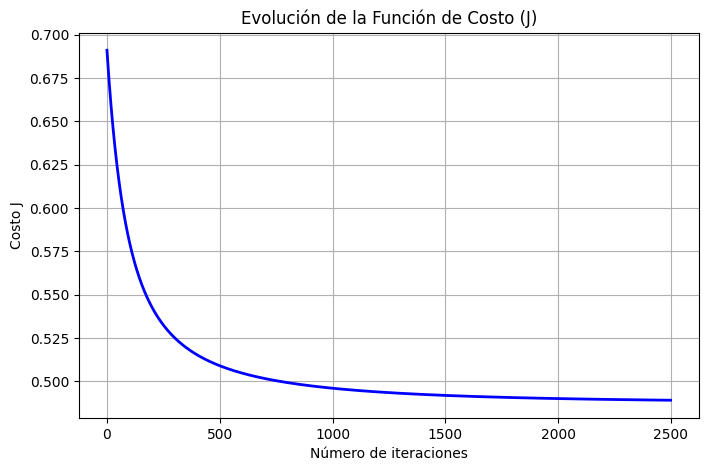

In [7]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['seasonal_vaccine'])
y = df_final['seasonal_vaccine']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_np = X_train.values
y_train_np = y_train.values

X_norm, mu, sigma = featureNormalize(X_train_np)

m_train, n_train = X_norm.shape
X_ready = np.concatenate([np.ones((m_train, 1)), X_norm], axis=1)

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

        if (i % 500 == 0):
            print(f"Iteración {i:4d} | Costo J: {J_history[-1]:.4f}")

    return theta, J_history

alpha = 0.01
num_iters = 2500
theta_inicial = np.zeros(n_train + 1)

print("\nIniciando entrenamiento...")
theta_optimo, J_history = descensoGradiente(theta_inicial, X_ready, y_train_np, alpha, num_iters)
print("\n¡Entrenamiento finalizado!")

pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.title("Evolución de la Función de Costo (J)")
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.grid(True)
pyplot.show()

## 6. Validación y Resultados Finales
Se evalúa el rendimiento general del modelo predictivo utilizando el conjunto de datos de validación apartado al principio (20% restante), asegurando que el modelo no ha memorizado datos previamente vistos.

In [8]:
X_test_np = X_test.values
y_test_np = y_test.values

X_test_norm = (X_test_np - mu) / sigma

m_test = X_test_norm.shape[0]
X_test_ready = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

probabilidades = sigmoid(np.dot(X_test_ready, theta_optimo))
predicciones_binarias = (probabilidades >= 0.5).astype(int)

aciertos = np.sum(predicciones_binarias == y_test_np)
precision = (aciertos / m_test) * 100

print("-" * 50)
print("RESULTADOS DE LA VALIDACIÓN (20% DE PRUEBA)")
print("-" * 50)
print(f"Total de casos de prueba: {m_test}")
print(f"Predicciones correctas:   {aciertos}")
print(f"Precisión del modelo:     {precision:.2f}%")
print("-" * 50)

print("\nAlgunos ejemplos de predicción:")
for i in range(10):
    print(f"Ejemplo {i+1:2d} | Probabilidad: {probabilidades[i]:.4f} -> Predice: {predicciones_binarias[i]} | Valor Real: {y_test_np[i]}")

--------------------------------------------------
RESULTADOS DE LA VALIDACIÓN (20% DE PRUEBA)
--------------------------------------------------
Total de casos de prueba: 5342
Predicciones correctas:   4153
Precisión del modelo:     77.74%
--------------------------------------------------

Algunos ejemplos de predicción:
Ejemplo  1 | Probabilidad: 0.4454 -> Predice: 0 | Valor Real: 0
Ejemplo  2 | Probabilidad: 0.3419 -> Predice: 0 | Valor Real: 1
Ejemplo  3 | Probabilidad: 0.7491 -> Predice: 1 | Valor Real: 0
Ejemplo  4 | Probabilidad: 0.2429 -> Predice: 0 | Valor Real: 0
Ejemplo  5 | Probabilidad: 0.2579 -> Predice: 0 | Valor Real: 0
Ejemplo  6 | Probabilidad: 0.9060 -> Predice: 1 | Valor Real: 1
Ejemplo  7 | Probabilidad: 0.7473 -> Predice: 1 | Valor Real: 1
Ejemplo  8 | Probabilidad: 0.8360 -> Predice: 1 | Valor Real: 1
Ejemplo  9 | Probabilidad: 0.2746 -> Predice: 0 | Valor Real: 0
Ejemplo 10 | Probabilidad: 0.9290 -> Predice: 1 | Valor Real: 1
